# Comparative Analysis 2

We conducted a comparative analysis of the image processing workflows created using the base visual programming language for image processing (VPL4IP) and those enhanced by our im2im library. Additionally, we evaluated the technical demands placed on users when building these workflows. Both versions of VPL4IP are developed on the Blockly framework.

The source code can be found on GitHub in our [GitHub repo](https://github.com/c3di/im2im).


**NOTE:**  Blockly for both versions of VPL4IP, does not include an execution environment. Therefore, to demonstrate and validate the functionality of our im2im library, we manually copied the generated code from the VPL4IPs interface and executed the code in colab. This manual process was necessary to verify that our library operates as intended.

**NOTE:** test_image is from *Diffusion-based deep learning method for augmenting ultrastructural imaging and volume electron microscopy,” Nat. Commun., vol. 15, no. 1, p. 4677, 2024, doi: 10.1038/s41467-024-49125-z.*

In [ ]:
!pip install git+https://github.com/c3di/im2im.git

  Cloning https://github.com/c3di/im2im.git to /tmp/pip-req-build-ejloqp54
  Running command git clone --filter=blob:none --quiet https://github.com/c3di/im2im.git /tmp/pip-req-build-ejloqp54
  Resolved https://github.com/c3di/im2im.git to commit be584f874b6098074e13119f13ef9929275483f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for im2im: filename=im2im-0.0.4.dev54+gbe584f8-py3-none-any.whl size=27007 sha256=38fa62850ba2a0e5e6a88db9dad8b7c474921c2f193bb7f5f62403b226ca2f40
  Stored in directory: /tmp/pip-ephem-wheel-cache-pm4wn7aa/wheels/f6/da/d9/016bcaab8aa1d64b11c731813af453063884f05b2b61b34c2d
Successfully built im2im


In [ ]:
import requests

def download_file(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as file:
            file.write(response.content)
        print(f"File downloaded successfully and saved to {save_path}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")

In [ ]:
import base64
from IPython.display import IFrame, display

def display_VPL4IP(html_file_path, width=1200, height=900):
  with open(html_file_path, 'r') as file:
      html_content = file.read()
  html_base64 = base64.b64encode(html_content.encode()).decode()
  data_uri = f"data:text/html;base64,{html_base64}"
  display(IFrame(data_uri, width, height))

## Prepare the execution environment for deep learning model for super resolution
for more detail in https://github.com/Max-ChenFei/super_resolution and https://github.com/Luchixiang/EMDiffuse

**NOTE**: Our goal is to showcase the functionality of our library, not to invest extensive effort in developing a comprehensive visual programming environment. Some elements are hardcoded for a quick demonstration.

In [ ]:
!git clone https://github.com/Luchixiang/EMDiffuse
#Must be in the EMDiffuse directory to run the EMDiffuse code
%cd EMDiffuse/
!pip install -r requirements.txt
download_file('https://raw.githubusercontent.com/Max-ChenFei/super_resolution/main/api.py', 'api.py')

Cloning into 'EMDiffuse'...
remote: Enumerating objects: 925, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 925 (delta 124), reused 256 (delta 113), pack-reused 653 (from 1)
Receiving objects: 100% (925/925), 80.20 MiB | 15.25 MiB/s, done.
Resolving deltas: 100% (422/422), done.
/content/EMDiffuse
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_

In [ ]:
source_file_directory = 'https://raw.githubusercontent.com/c3di/im2im/main/comparative_analysis/2'

In [ ]:
import os

test_image_path = os.path.join(source_file_directory, "image.tif")
download_file(test_image_path, 'image.tif')

File downloaded successfully and saved to image.tif


## Base VPL4IP with Manual Conversion

In [ ]:
path = 'base_VPL4IP.html'
download_file(os.path.join(source_file_directory, "base_VPL4IP.html"), path)
display_VPL4IP(path, 1700, 1200)

File downloaded successfully and saved to base_VPL4IP.html


**Textual Code generated from the Workflow**


In [ ]:
from skimage.exposure import equalize_adapthist
import numpy as np
import torch
from api import super_resolution
from skimage.filters import gaussian
from skimage.io import imread

raw_image = imread('image.tif', as_gray=True)

gaussian_filtered = gaussian(raw_image, sigma=0.5)

if torch.cuda.is_available():
    image = torch.unsqueeze(torch.unsqueeze(torch.from_numpy(gaussian_filtered.astype(np.float32)), 0), 0).cuda()

super_res_image = super_resolution(image, 2)

contrast_enhanced = equalize_adapthist(np.squeeze(super_res_image.cpu().detach().numpy()))

results and model will be saved in experiments/test_EMDiffuse-r_240815_160039


INFO:test:Create the log file in directory experiments/test_EMDiffuse-r_240815_160039.

INFO:test:Dataset [EMDiffusenDataset() form data.dataset] is created.
INFO:test:Dataset for test have 0 samples.
INFO:test:Network [Network() form models.EMDiffuse_network] is created.
INFO:test:Metric [mae() form models.metric] is created.
INFO:test:Loss [mse_loss() form models.loss] is created.
INFO:test:Beign loading pretrained model [Network] ...
INFO:test:Loading pretrained model from [./experiments/EMDiffuse-r/best_Network.pth] ...
INFO:test:Beign loading pretrained model [Network_ema] ...
INFO:test:Loading pretrained model from [./experiments/EMDiffuse-r/best_Network_ema.pth] ...
INFO:test:Model [DiReP() form models.EMDiffuse_model] is created.
sampling loop time step: 100%|██████████| 200/200 [00:12<00:00, 15.93it/s]


**Results Inspection**

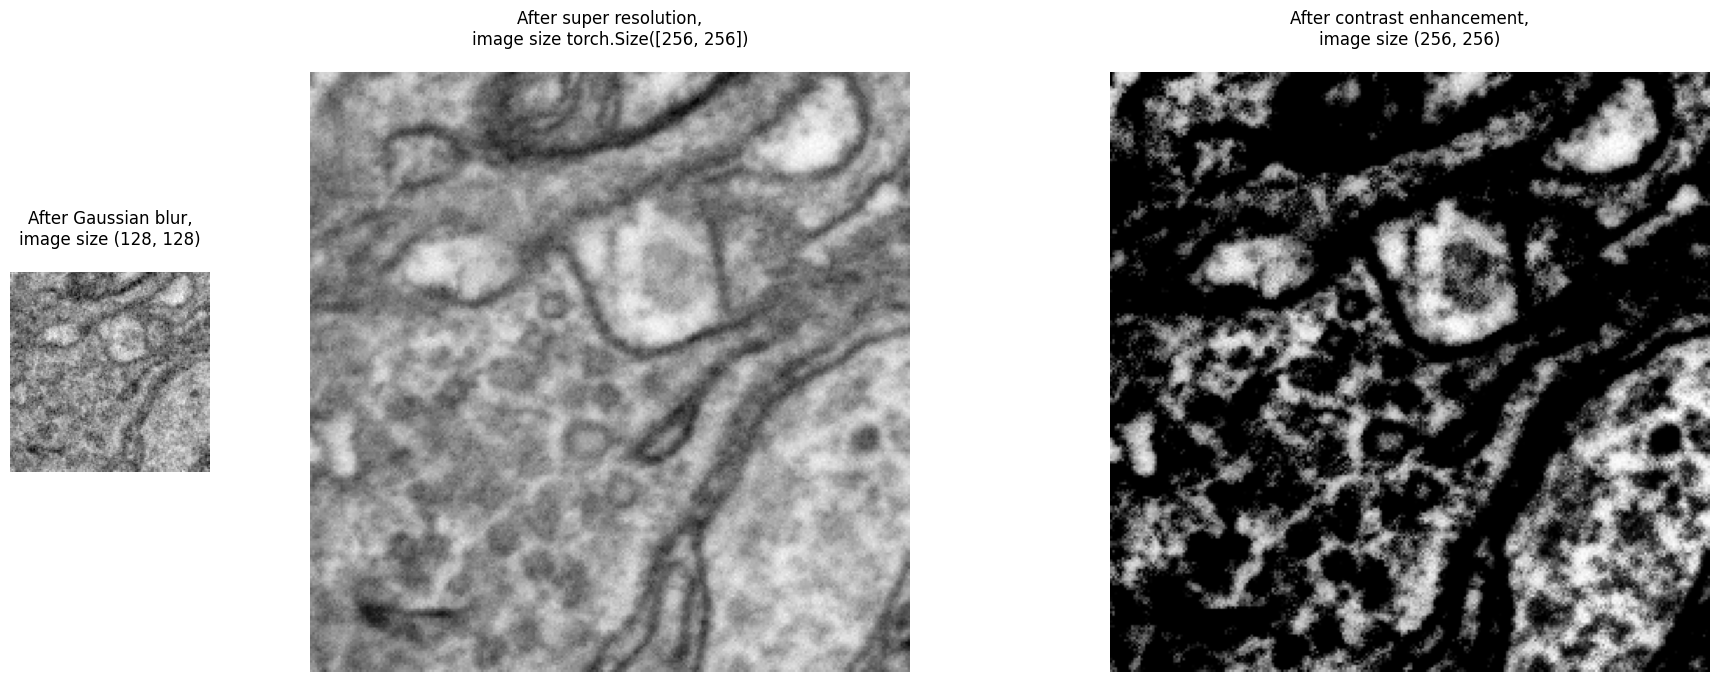

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, width_ratios=[1, 4, 4])
gs.update(wspace=0, hspace=0)

ax0 = fig.add_subplot(gs[0])
ax0.imshow(gaussian_filtered, cmap='gray')
ax0.set_title(f'After Gaussian blur,\nimage size {gaussian_filtered.shape}', pad=20)
ax0.axis('off')

ax1 = fig.add_subplot(gs[1])
ax1.imshow(super_res_image.cpu().squeeze(), cmap='gray')
ax1.set_title(f'After super resolution,\nimage size {super_res_image.squeeze().shape}', pad=20)
ax1.axis('off')

ax2 = fig.add_subplot(gs[2])
ax2.imshow(contrast_enhanced, cmap='gray')
ax2.set_title(f'After contrast enhancement,\nimage size {contrast_enhanced.shape}', pad=20)
ax2.axis('off')


fig.patch.set_visible(False)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

## Enhanced VPL4IP by our im2im library

In [ ]:
path = 'enhanced_VPL4IP.html'
download_file(os.path.join(source_file_directory, "enhanced_VPL4IP.html"), path)
display_VPL4IP(path, 1700, 1200)

File downloaded successfully and saved to enhanced_VPL4IP.html


**Textual Code generated from the Workflow**


In [ ]:
from im2im import Image, im2im
from skimage.exposure import equalize_adapthist
from api import super_resolution
from skimage.filters import gaussian
from im2im import Image, im2im, get_possible_metadata
from skimage.io import imread

raw_image = Image(imread('image.tif', as_gray=True), {**get_possible_metadata('skimage.gray'), 'image_data_type': 'uint8'})

in_im1 = im2im(raw_image, 'skimage.before_gaussian')
e_gaussian_filtered = gaussian(in_im1.raw_image, sigma=0.5)
out_im = Image(e_gaussian_filtered, {**in_im1.metadata, 'image_data_type': 'float64(0to1)'})

in_im2 = im2im(out_im, 'torch.gpu')
e_super_res_image = super_resolution(in_im2.raw_image, 2)
out_im2 = Image(e_super_res_image, in_im2.metadata)

in_im3 = im2im(out_im2, 'skimage.before_equalize_adapthist')
e_contrast_enhanced = equalize_adapthist(in_im3.raw_image)
out_im3 = Image(e_contrast_enhanced, {**in_im3.metadata, 'image_data_type': 'float64(0to1)'})

sampling loop time step: 100%|██████████| 200/200 [00:13<00:00, 15.24it/s]


**Results Inspection**

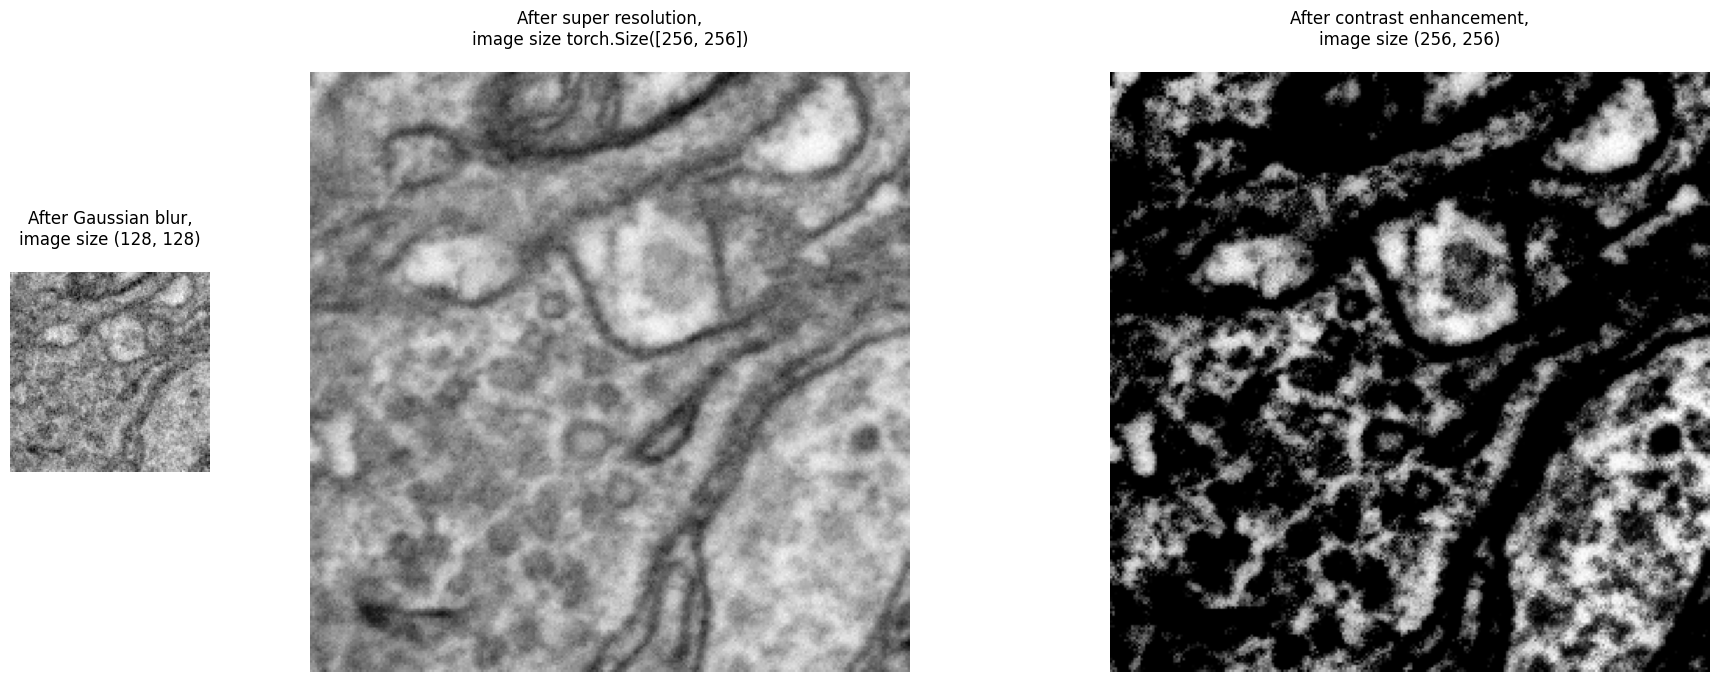

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, width_ratios=[1, 4, 4])
gs.update(wspace=0, hspace=0)

ax0 = fig.add_subplot(gs[0])
ax0.imshow(gaussian_filtered, cmap='gray')
ax0.set_title(f'After Gaussian blur,\nimage size {e_gaussian_filtered.shape}', pad=20)
ax0.axis('off')

ax1 = fig.add_subplot(gs[1])
ax1.imshow(super_res_image.cpu().squeeze(), cmap='gray')
ax1.set_title(f'After super resolution,\nimage size {e_super_res_image.squeeze().shape}', pad=20)
ax1.axis('off')

ax2 = fig.add_subplot(gs[2])
ax2.imshow(contrast_enhanced, cmap='gray')
ax2.set_title(f'After contrast enhancement,\nimage size {e_contrast_enhanced.shape}', pad=20)
ax2.axis('off')


fig.patch.set_visible(False)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

## Inspection of Results After Processing Steps

The first reason for the variation in results is related to the diffusion-based deep learning model we used for super-resolution [1]. Diffusion models are generative models that learn the underlying distribution of training data by gradually adding and removing noise, which introduces inherent variability in the outputs [2].The second reason lies in the inherent randomness within the PyTorch framework [3]. Even after fixing randomness in PyTorch, NumPy, and cuDNN, we observed that results for the same input remains not identical [4] for used model. Therefore, we decided to skip direct comparison of results after each processing step and instead focus on reviewing the underlying conversion code provided below.



[1]: [Diffusion-based deep learning method for augmenting ultrastructural imaging and volume electron microscopy | Nature Communications](https://doi.org/10.1038/s41467-024-49125-z)   
[2]: [On the Design Fundamentals of Diffusion Models: A Survey](https://arxiv.org/abs/2306.04542)   
[3]: [PyTorch Randomness](https://pytorch.org/docs/stable/notes/randomness.html)   
[4]: [Colab Notebook for Super-Resolution](https://github.com/Max-ChenFei/super_resolution/blob/main/usage_in_colab.ipynb)

## Inspection of Underlying Conversion Code
The conversion code successfully achieved our intended results, producing outcomes consistent with the conversion steps in the base VPL4IP.

In [ ]:
from im2im import im2im_code

# Assuming 'source' and 'target' are the names of the input and output images
print(f"Conversion Code from Gaussian blur to Super resolution:\n\n{im2im_code('source', out_im.metadata, 'target', in_im2.metadata)}\n")
print(f"Conversion Code from Super resolution to Contrast enhancement:\n\n{im2im_code('source', out_im2.metadata, 'target', in_im3.metadata)}")

Conversion Code from Gaussian blur to Super resolution:

import torch
from torchvision.transforms.v2 import functional as F
image = torch.from_numpy(source)
image = image.unsqueeze(0)
image = image.unsqueeze(0)
image = F.to_dtype(image, torch.float, scale=True)
target = image.cuda()

Conversion Code from Super resolution to Contrast enhancement:

import torch
image = source.squeeze(0)
image = image.squeeze(0)
image = image.cpu()
target = image.numpy(force=True)
